In [ ]:
import pandas as pd
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [ ]:

df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
print(df.shape)

print(df.columns)

print(df.info())

print(df['sentiment'].value_counts())

(50000, 2)
Index(['review', 'sentiment'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [ ]:
def clean_text(text):

   # convert to lowercase
    text = text.lower()

     # remove html tags
    text = re.sub(r'<.*?>', '', text)

     # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    return text





In [ ]:
df['review'] = df['review'].apply(clean_text)

In [ ]:
df['review']

,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production the filming tech...
2,i thought this was a wonderful way to spend ti...
3,basically theres a family where a little boy j...
4,petter matteis love in the time of money is a ...
...,...
49995,i thought this movie did a down right good job...
49996,bad plot bad dialogue bad acting idiotic direc...
49997,i am a catholic taught in parochial elementary...
49998,im going to have to disagree with the previous...


In [ ]:
df['review'].head()

,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production the filming tech...
2,i thought this was a wonderful way to spend ti...
3,basically theres a family where a little boy j...
4,petter matteis love in the time of money is a ...


In [ ]:
tokenizer = Tokenizer(num_words=10000)

In [ ]:
tokenizer.fit_on_texts(df['review'])

In [ ]:
sequences = tokenizer.texts_to_sequences(df['review'])

In [ ]:
print(sequences[0])

[27, 4, 1, 77, 1913, 42, 1050, 11, 100, 144, 39, 3268, 390, 456, 25, 3114, 33, 22, 205, 13, 10, 6, 589, 46, 579, 14, 7419, 87, 145, 11, 3189, 68, 41, 3268, 12, 28, 5435, 2, 131, 4, 580, 60, 283, 7, 205, 35, 1, 657, 137, 1708, 68, 10, 6, 20, 3, 117, 15, 1, 8025, 5627, 38, 10, 117, 2455, 54, 5838, 14, 5541, 5, 1444, 380, 38, 580, 28, 6, 3349, 7, 1, 350, 339, 4, 1, 6, 460, 3268, 13, 11, 6, 1, 344, 5, 1, 6687, 2513, 1047, 8, 2579, 1351, 19, 529, 32, 4623, 2472, 4, 1, 1185, 112, 30, 1, 6896, 24, 2914, 2, 404, 37, 6, 20, 317, 19, 1, 4959, 3632, 529, 6, 341, 5, 8150, 5051, 7611, 2410, 2, 327, 8931, 7205, 2, 8400, 22, 108, 225, 56, 124, 1, 268, 1274, 4, 1, 117, 6, 659, 5, 1, 186, 11, 8, 261, 112, 77, 255, 544, 2937, 813, 178, 1247, 4242, 15, 2451, 1084, 813, 1389, 813, 146, 963, 181, 1, 87, 390, 9, 119, 202, 3189, 68, 13, 37, 1552, 8, 12, 2169, 9, 393, 124, 9, 12, 1527, 15, 8, 17, 13, 9, 277, 49, 9, 1441, 3, 1225, 15, 3268, 2, 182, 9902, 5, 1, 317, 2050, 4, 2061, 580, 20, 39, 580, 17, 7678, 68

In [ ]:
max_length = 220
X = pad_sequences(sequences, maxlen=max_length,  padding='post', truncating='post')

In [ ]:
print(X.shape)

(50000, 220)


In [ ]:
print(X[0])

[  27    4    1   77 1913   42 1050   11  100  144   39 3268  390  456
   25 3114   33   22  205   13   10    6  589   46  579   14 7419   87
  145   11 3189   68   41 3268   12   28 5435    2  131    4  580   60
  283    7  205   35    1  657  137 1708   68   10    6   20    3  117
   15    1 8025 5627   38   10  117 2455   54 5838   14 5541    5 1444
  380   38  580   28    6 3349    7    1  350  339    4    1    6  460
 3268   13   11    6    1  344    5    1 6687 2513 1047    8 2579 1351
   19  529   32 4623 2472    4    1 1185  112   30    1 6896   24 2914
    2  404   37    6   20  317   19    1 4959 3632  529    6  341    5
 8150 5051 7611 2410    2  327 8931 7205    2 8400   22  108  225   56
  124    1  268 1274    4    1  117    6  659    5    1  186   11    8
  261  112   77  255  544 2937  813  178 1247 4242   15 2451 1084  813
 1389  813  146  963  181    1   87  390    9  119  202 3189   68   13
   37 1552    8   12 2169    9  393  124    9   12 1527   15    8   17
   13 

In [ ]:
y = df['sentiment'].map({
    'positive': 1,
    'negative': 0
})

In [ ]:
print(y.head())

0    1
1    1
2    1
3    0
4    1
Name: sentiment, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(40000, 220)
(10000, 220)


In [ ]:
model = Sequential([

    Embedding(input_dim=10000, output_dim=128, input_length=220),

    LSTM(128),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.build(input_shape=(None, 220))

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 220, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411,713 (5.39 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
import time
start = time.time()
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    shuffle=True ,
    callbacks=[early_stop]
)
end = time.time()

lstm_time = end - start
print("LSTM Time:", lstm_time)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.5100 - loss: 0.6932 - val_accuracy: 0.5231 - val_loss: 0.6904
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.5546 - loss: 0.6701 - val_accuracy: 0.5686 - val_loss: 0.6583
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.7310 - loss: 0.5191 - val_accuracy: 0.8144 - val_loss: 0.4117
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8847 - loss: 0.2888 - val_accuracy: 0.8648 - val_loss: 0.3417
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9254 - loss: 0.2036 - val_accuracy: 0.8619 - val_loss: 0.3459
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9487 - loss: 0.1491 - val_accuracy: 0.8677 - val_loss: 0.3839
LSTM Time: 46.119632959365845


In [ ]:
lstm_loss, lstm_acc = model.evaluate(X_test, y_test)

print("LSTM Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8621 - loss: 0.3341
LSTM Accuracy: 0.8621000051498413


In [ ]:
gru_model = Sequential([

    Embedding(input_dim=10000, output_dim=128, input_length=220),

    GRU(128),

    Dense(1, activation='sigmoid')
])

In [ ]:
gru_model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
gru_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
import time

start = time.time()

gru_history = gru_model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    shuffle=True,
    callbacks=[gru_early_stop]
)

end = time.time()

gru_time = end - start
print("GRU Time:", gru_time)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.5095 - loss: 0.6958 - val_accuracy: 0.5274 - val_loss: 0.6854
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7462 - loss: 0.4785 - val_accuracy: 0.8696 - val_loss: 0.3093
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9112 - loss: 0.2296 - val_accuracy: 0.8791 - val_loss: 0.2976
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9467 - loss: 0.1498 - val_accuracy: 0.8764 - val_loss: 0.3547
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9700 - loss: 0.0950 - val_accuracy: 0.8674 - val_loss: 0.4277
GRU Time: 36.022461891174316


In [ ]:
gru_loss, gru_acc = gru_model.evaluate(X_test, y_test)

print("GRU Accuracy:", gru_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8797 - loss: 0.2893
GRU Accuracy: 0.8797000050544739


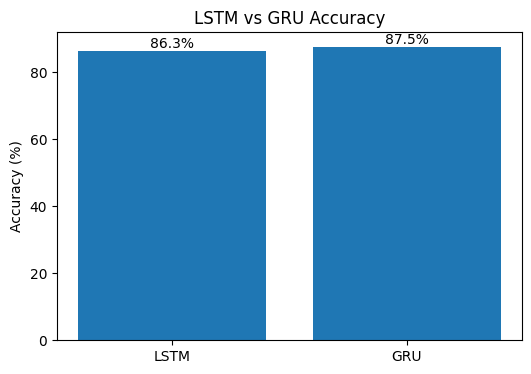

In [ ]:
import matplotlib.pyplot as plt

models = ['LSTM', 'GRU']
accuracies = [86.3, 87.5]

plt.figure(figsize=(6,4))

bars = plt.bar(models, accuracies)

plt.title("LSTM vs GRU Accuracy")
plt.ylabel("Accuracy (%)")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f'{yval:.1f}%',
        ha='center',
        va='bottom'
    )

plt.show()

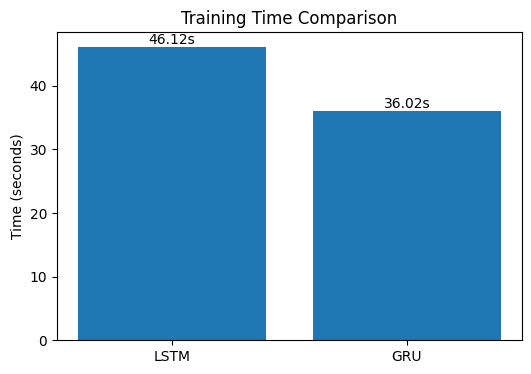

In [ ]:
times = [lstm_time, gru_time]

plt.figure(figsize=(6,4))

bars = plt.bar(models, times)

plt.title("Training Time Comparison")
plt.ylabel("Time (seconds)")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f'{yval:.2f}s',
        ha='center',
        va='bottom'
    )

plt.show()

In [ ]:
model.save("n_lstm_model.h5")

In [ ]:
gru_model.save("n_gru_model.h5")

In [ ]:
from google.colab import files

files.download("n_lstm_model.h5")
files.download("n_gru_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle
with open("n_tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

In [ ]:
from google.colab import files

files.download("n_tokenizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>